# Implied Volatility Surface Builder

Pull AAPL options data, compute implied volatility for each contract using Black-Scholes inversion,  
and plot the result as a 3D surface (strike × time to expiry × IV).

In [7]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import brentq
from scipy.stats import norm
import plotly.graph_objects as go
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [8]:
# Black-Scholes call price
def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# solve for implied vol using Brent's method
def implied_vol(price, S, K, T, r):
    try:
        iv = brentq(lambda sigma: bs_call(S, K, T, r, sigma) - price, 0.01, 5.0)
        return iv
    except:
        return np.nan

In [9]:
# fetch current spot price and available expiry dates
ticker = yf.Ticker('AAPL')
spot = ticker.history(period='1d')['Close'].iloc[-1]
expiries = ticker.options

print(f'Spot price: ${spot:.2f}')
print(f'Available expiry dates: {len(expiries)}')
print(list(expiries[:8]))

Spot price: $258.83
Available expiry dates: 24
['2026-04-15', '2026-04-17', '2026-04-20', '2026-04-22', '2026-04-24', '2026-05-01', '2026-05-08', '2026-05-15']


In [10]:
# compute implied vol for each call option across multiple expiries
r = 0.05  # risk-free rate
results = []

# use more expiries to get a richer surface
n_expiries = min(12, len(expiries))

for exp in expiries[:n_expiries]:
    chain = ticker.option_chain(exp)
    calls = chain.calls

    T = (pd.Timestamp(exp) - pd.Timestamp.now()).days / 365
    if T <= 0.003:  # skip same-day expiry
        continue

    for _, row in calls.iterrows():
        K = row['strike']

        # use mid price if available, otherwise fall back to lastPrice
        if row['bid'] > 0 and row['ask'] > 0:
            price = (row['bid'] + row['ask']) / 2
        elif row['lastPrice'] > 0:
            price = row['lastPrice']
        else:
            continue

        if K < spot * 0.7 or K > spot * 1.3:
            continue

        iv = implied_vol(price, spot, K, T, r)

        if not np.isnan(iv) and 0.05 < iv < 2.0:
            results.append({
                'expiry': exp,
                'strike': K,
                'T': round(T, 4),
                'iv': round(iv, 4),
                'mid_price': round(price, 2)
            })

df = pd.DataFrame(results)
print(f'Computed {len(df)} implied volatilities')
df.head(10)

Computed 235 implied volatilities


,expiry,strike,T,iv,mid_price
0,2026-04-20,230.0,0.011,0.9783,30.48
1,2026-04-20,235.0,0.011,0.4076,24.00
2,2026-04-20,237.5,0.011,0.5361,21.83
3,2026-04-20,242.5,0.011,0.4202,16.79
4,2026-04-20,250.0,0.011,0.3103,9.55
5,2026-04-20,252.5,0.011,0.2328,6.95
6,2026-04-20,255.0,0.011,0.2696,5.30
7,2026-04-20,257.5,0.011,0.2790,3.80
8,2026-04-20,260.0,0.011,0.2841,2.59
9,2026-04-20,262.5,0.011,0.2807,1.61


In [11]:
# 3D volatility surface
fig = go.Figure(data=[go.Mesh3d(
    x=df['strike'],
    y=df['T'],
    z=df['iv'],
    intensity=df['iv'],
    colorscale='Viridis',
    opacity=0.75,
    colorbar_title='IV'
)])

fig.update_layout(
    title='Implied Volatility Surface — AAPL',
    scene=dict(
        xaxis_title='Strike Price ($)',
        yaxis_title='Time to Expiry (years)',
        zaxis_title='Implied Volatility'
    ),
    width=900,
    height=700
)

fig.show()

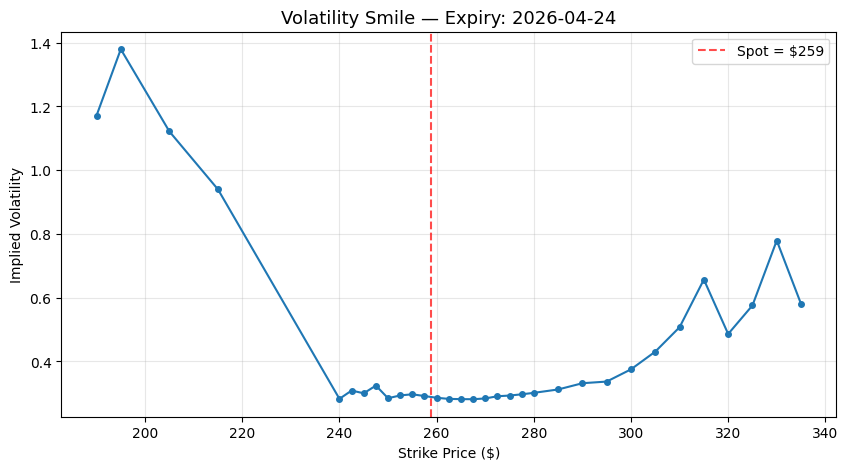

In [12]:
# 2D volatility smile for a single expiry
available = df['expiry'].unique()
target_exp = available[min(2, len(available) - 1)]
smile = df[df['expiry'] == target_exp].sort_values('strike')

plt.figure(figsize=(10, 5))
plt.plot(smile['strike'], smile['iv'], 'o-', markersize=4)
plt.axvline(spot, color='red', linestyle='--', alpha=0.7, label=f'Spot = ${spot:.0f}')
plt.title(f'Volatility Smile — Expiry: {target_exp}', fontsize=13)
plt.xlabel('Strike Price ($)')
plt.ylabel('Implied Volatility')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Observations

The surface shows the typical volatility skew — OTM puts (lower strikes) tend to have higher implied vol than OTM calls (higher strikes). This reflects the market pricing in higher probability of large downside moves compared to upside.

You can also see how the skew changes across expiries (the term structure). Near-term options tend to have steeper skew, while longer-dated ones flatten out. This is consistent with the idea that short-term crash risk is priced more aggressively.

Since this uses live data, the surface will look different each time you run it.